1st clone repo to working directory

In [1]:
import git

repo = git.Repo.clone_from(
    "https://github.com/frankmollard/fuzzyfier",
    "./fuzzyfier"
)

In [1]:
import sys

2nd append path to environmental variables

In [2]:
sys.path.append("./fuzzyfier/src")

In [3]:
import numpy as np 
from matplotlib import pyplot as plt
from fuzzyfication import fuzzyfication

> In this norebook, we show how a simple stock-picking strategy can be developed using fuzzy logic. This is a simple example that should not be implemented as-is in practice, since more complex conditions are typically used when making buy or sell decisions. 

# Simulation

In this simulation, simple rules are applied to further illustrate the functioning of Fuzzy. Securities are always sold when their value increases and we hold few or a moderate number in the portfolio. We sell when we hold many or a moderate number and the value declines. Random trajectories are generated for this purpose. Additionally, a general market trend is assumed, as this strategy can only be effective if there is an overall positive trend.

stock and marketTrend are the experts conditions

In [6]:
stock = {"small": 0, "middle": 100, "high": 500}
marketTrend= {"negative": -4, "stagnation": 0, "positive": 4}

## Value of Portfolio

The Value is calculated for n Stocks by 

$$ \sum_{i=1}^{n} No~of~Stock_i \cdot price_i $$

additionally the earnings through sales and purchases are taken into account.

The following function reacts to the market trends usinf fuzzy and calculates the development of the number of shares, the sales, purchases, and the value of the portfolio.

In [17]:
def portfolioTrend(marketValues, growth, startStock, maxBuy):
    noOfShares = [startStock]
    sales = []
    purchases = []
    assetValue = [startStock*marketValues[0]]
    
    for i in range(len(growth)):
    
        fS1=fuzzyfication(stock, startStock)
        fMT1=fuzzyfication(marketTrend, growth[i])
    
        c1 = np.min([np.max([fS1.fuzzy()["middle"], fS1.fuzzy()["small"]]), fMT1.fuzzy()["negative"]]) #buy
        c2 = np.min([np.max([fS1.fuzzy()["middle"], fS1.fuzzy()["high"]]), fMT1.fuzzy()["positive"]]) #sell
        #c3 = np.min([np.max([fS1.fuzzy()["middle"], fS1.fuzzy()["high"]]), fMT1.fuzzy()["stagnation"]]) #hold
        
        activations = {"Buy": c1, "Sell": c2}#, "Hold": c3}
        decisions = {k: int(np.round(v*maxBuy)) if k == "Buy" else int(np.round(v*startStock)) for k, v in activations.items()}
    
        startStock = startStock + decisions["Buy"]
        purchase = decisions["Buy"] * marketValues[i+1]
        purchases.append(purchase)
        
        #avtivationsHold = {k: v for k, v in activations.items() if k not in ["Buy"]}
        #avtivationsHold["Hold"] = 1 - avtivationsHold["Hold"]
        
        #resultingValuesSell = list({k: v for k, v in decisions.items() if k not in ["Buy"]}.values())
        #resultingValuesSell[1] = startStock - resultingValuesSell[1]
        
        #sell = fS1.defuzzification(avtivationsHold, resultingValuesSell)
    
        startStock = startStock - decisions["Sell"]#sell[0]
        revenue = decisions["Sell"] * marketValues[i+1]
        sales.append(revenue)
    
        noOfShares.append(startStock)
        assetValue.append(startStock * marketValues[i+1])
        
    return {"NoShares": np.array(noOfShares), "Sales": np.array(sales), "Purchases": np.array(purchases), "AssetValue": np.array(assetValue)}

Loop over simulated market trends

Mean Fuzzy 5491.825271225355
Mean bah 5247.935995664449


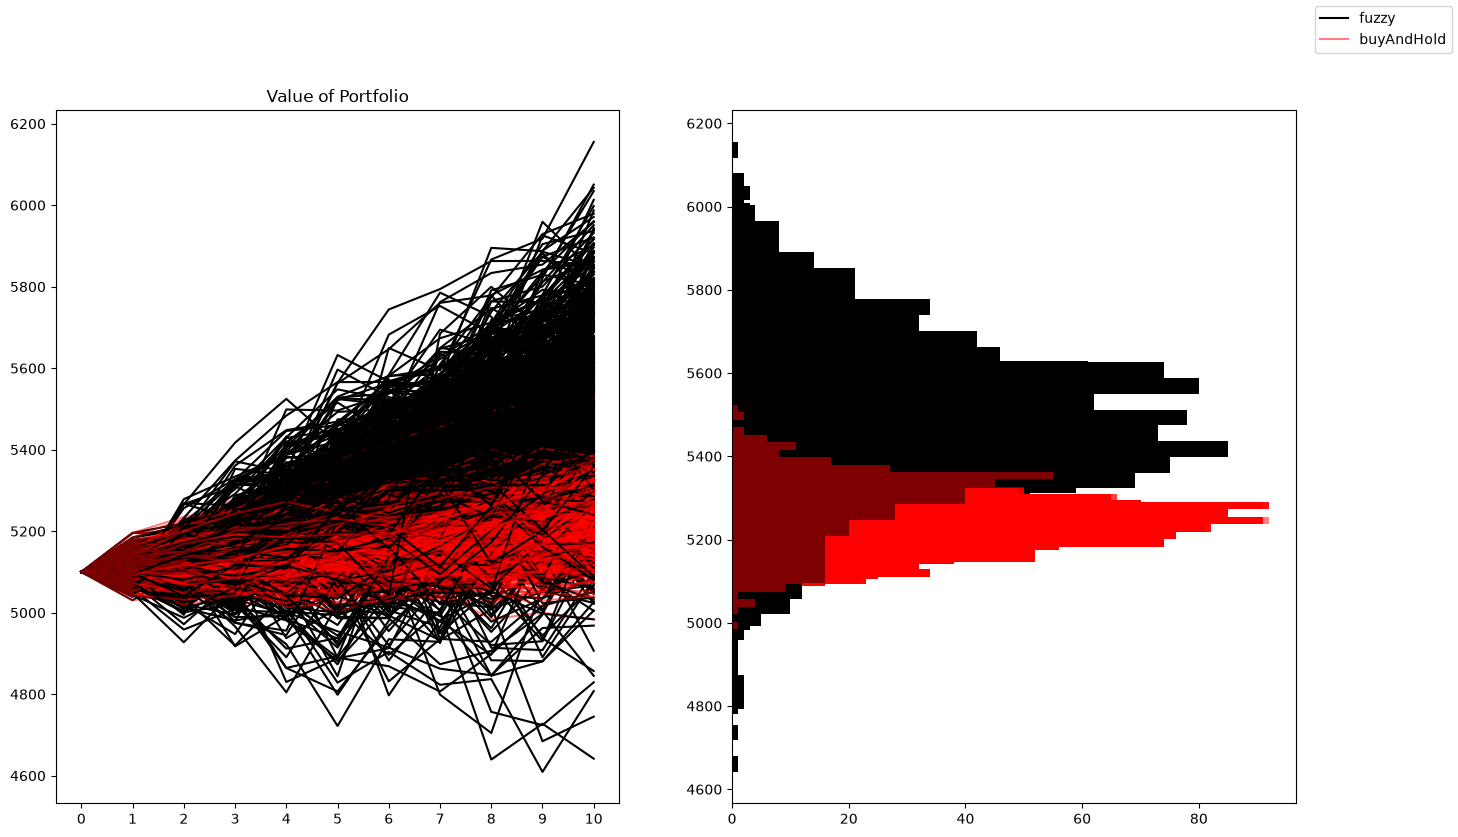

In [35]:
noOfShares = 100
periods=10
fig, p = plt.subplots(1, 2, figsize=(16,9))#, sharey=True)
p[0].set_title("Value of Portfolio")

lVBAH = []
lVF = []

for s in range(1000):
    np.random.seed(1+s)
    gs = np.random.normal(loc=0.0, scale=0.005, size=periods)
    
    share1 = [51]
    trend=0.05
    for g in gs:
        share1.append(share1[-1]*(1+g.item()) + t*trend)
    
    share1Heistory = portfolioTrend(share1, gs*100, noOfShares, 1000)
    
    
    earnings = -share1Heistory["Purchases"] + share1Heistory["Sales"] 
    earnings = np.cumsum(earnings)
    earnings = earnings.tolist()
    earnings.insert(0, 0)
    
    #print("Portfolio value + earnings", share1Heistory["AssetValue"] + earnings)
    fuzzyControll = share1Heistory["AssetValue"]  + earnings
    lVF.append(fuzzyControll[-1])
    
    buyAndHold = np.array(share1) * noOfShares
    lVBAH.append(buyAndHold[-1])
    
    p[0].plot(fuzzyControll, color="black", label="fuzzy" if s == 0 else None)
    p[0].plot(buyAndHold, color="red", alpha=0.5, label="buyAndHold" if s == 0 else None)

    p[1].hist(lVF, color="black", orientation="horizontal", bins=40)
    p[1].hist(lVBAH, color="red", alpha=0.5, orientation="horizontal", bins=30)
    
p[0].set_xticks(range(periods+1))
fig.legend()
print("Mean Fuzzy", np.mean(np.array(lVF)))
print("Mean bah", np.mean(np.array(lVBAH)))
plt.show()

In conclusion, automated stock-picking demonstrates significantly superior outcomes, as it effectively capitalizes on gains. However, it should be noted that in a persistently declining market, disadvantages are to be expected, because purchases are continuously made at comparatively high prices. If a discernible market trend exists, an optimal scenario would resemble a U-shaped pattern, allowing for initial acquisitions at lower prices and subsequent sales at higher prices. Such conditions are considerably more probable when the overall trend is upward. Nevertheless, this example also clearly illustrates that stock-picking exhibits substantial weaknesses in precisely these contexts, regardless of whether actions are executed by a human or a fuzzy algorithmic system.

Note that with the buy-and-hold strategy, the portfolio’s value was also increased by the profits; however, since no transactions took place, these profits were zero.